# 交換モンテカルロ法によるXPSスペクトル分解

このNotebookは、第3章第3節の数値実験を、同じ記号と人工データ条件で再現するチュートリアルです。
XPSのピーク位置・幅・強度には馴染みがある一方、ベイズ推論は初めてという読者を想定しています。

このNotebookで行うことは次の3つです。

1. 真値が既知の人工XPSスペクトルを作る。
2. 交換モンテカルロ法（EMC）の温度列から、ピーク数ごとのベイズ自由エネルギー $F(K)$ を求める。
3. 選ばれたピーク数 $K^*$ のもとで、$A_k, \mu_k, w_k$ を点ではなく事後分布として評価する。

> **この例の範囲**
> 教育用に、背景なし・ガウスピーク・既知のガウス雑音を仮定します。実測XPSに適用するときは、背景、
> Voigt系ピーク、装置関数、元素ごとの制約、雑音モデルなどを追加する必要があります。

In [1]:
from pathlib import Path
import csv
import json
import math
import os
import random
import subprocess
import sys
import warnings

import numpy as np


try:
    import google.colab  # type: ignore  # noqa: F401
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    colab_repo = Path("/content/bayesian-xps-spectral-analysis")
    if not colab_repo.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "https://github.com/motigome/bayesian-xps-spectral-analysis.git",
                str(colab_repo),
            ],
            check=True,
        )
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-e", f"{colab_repo}[plot]"],
        check=True,
    )
    os.chdir(colab_repo / "tutorials" / "02_xps_spectral_decomposition")
    print("Colab setup completed.")


def find_project_dir() -> Path:
    """Notebookをリポジトリ直下・tutorialディレクトリのどちらから開いても動かす。"""
    current = Path.cwd().resolve()
    if (current / "xps_spectral_decomposition.py").exists() or (
        current / "xps_spectral_decomposition.ipynb"
    ).exists():
        return current
    candidate = current / "tutorials" / "02_xps_spectral_decomposition"
    if candidate.exists():
        return candidate.resolve()
    raise FileNotFoundError("tutorials/02_xps_spectral_decomposition が見つかりません。")


PROJECT_DIR = find_project_dir()
REPO_ROOT = PROJECT_DIR.parents[1]
DATA_DIR = PROJECT_DIR / "data"
SRC_DIR = PROJECT_DIR / "src"
RESULT_DIR = PROJECT_DIR / "result"
for directory in (DATA_DIR, SRC_DIR, RESULT_DIR / "figures", PROJECT_DIR / ".cache" / "matplotlib"):
    directory.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_DIR / ".cache" / "matplotlib"))
warnings.filterwarnings("ignore", message=r"FigureCanvasAgg is non-interactive.*")
FAST_MODE = os.environ.get("BAYES_XPS_FAST", "0") == "1"

cli_env = os.environ.copy()
cli_env["PYTHONPATH"] = str(REPO_ROOT) + os.pathsep + cli_env.get("PYTHONPATH", "")


def run_cli(*args: str) -> None:
    """このリポジトリに同梱した bayes_emc CLI を呼ぶ。"""
    print("$ python -m bayes_emc", " ".join(args))
    completed = subprocess.run(
        [sys.executable, "-m", "bayes_emc", *args],
        cwd=PROJECT_DIR,
        env=cli_env,
        text=True,
        capture_output=True,
    )
    for output in (completed.stdout, completed.stderr):
        cleaned = output.replace(str(REPO_ROOT), "<repo>").strip()
        if cleaned:
            print(cleaned)
    completed.check_returncode()


print(f"project: {PROJECT_DIR.relative_to(REPO_ROOT)}")
print(f"fast mode: {FAST_MODE}")

project: tutorials/02_xps_spectral_decomposition
fast mode: False


## 1. 観測モデルを数式で書く

エネルギー $E_i$ における観測強度を、$K$ 個のピークと背景、観測誤差の和として

$$
y(E_i)=\sum_{k=1}^{K} A_k\,\phi(E_i\mid\mu_k,w_k)+b(E_i)+\epsilon_i
$$

と表します。このNotebookでは原稿の人工データ条件に合わせて $b(E_i)=0$ とし、

$$
\phi(E\mid\mu,w)=\exp\left[-\frac{(E-\mu)^2}{2w^2}\right],
\qquad \epsilon_i\sim\mathcal{N}(0,\sigma^2)
$$

を使います。$A_k$ はピーク高さ、$\mu_k$ はピーク位置、$w_k$ はガウス関数の標準偏差に対応する幅です。
原稿の式(37), (38), (41), (54)に対応します。

In [2]:
TRUE_PEAKS = [
    {"A": 0.6, "mu": 1.20, "w": 0.10},
    {"A": 1.5, "mu": 1.45, "w": 0.08},
    {"A": 1.2, "mu": 1.70, "w": 0.07},
]
K_TRUE = len(TRUE_PEAKS)
N = 300
SIGMA2 = 0.01
NOISE_SIGMA = math.sqrt(SIGMA2)
DATA_SEED = 20260804


def gaussian_peak(E, A, mu, w):
    """A * phi(E | mu, w): A is the peak height."""
    E = np.asarray(E, dtype=float)
    return A * np.exp(-0.5 * ((E - mu) / w) ** 2)


def spectrum(E, peaks):
    return sum(gaussian_peak(E, **peak) for peak in peaks)


energy = np.linspace(0.0, 3.0, N)
true_components = np.vstack([gaussian_peak(energy, **peak) for peak in TRUE_PEAKS])
true_signal = true_components.sum(axis=0)
# Python標準ライブラリの固定seedを使い、Notebookと検証スクリプトで同じ人工データを再現する。
data_rng = random.Random(DATA_SEED)
observed = true_signal + np.array(
    [data_rng.gauss(0.0, NOISE_SIGMA) for _ in range(N)],
    dtype=float,
)

data_path = DATA_DIR / "synthetic_xps.csv"
with data_path.open("w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file, lineterminator="\n")
    writer.writerow(["E", "y"])
    writer.writerows(zip(energy, observed))

print(f"wrote: {data_path.relative_to(PROJECT_DIR)}")
print(f"K_true={K_TRUE}, N={N}, sigma2={SIGMA2}, seed={DATA_SEED}")

wrote: data/synthetic_xps.csv
K_true=3, N=300, sigma2=0.01, seed=20260804


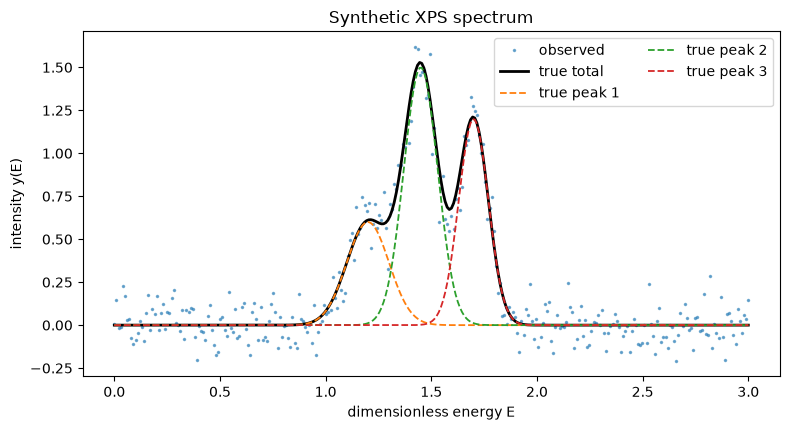

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8.0, 4.4))
ax.plot(energy, observed, ".", ms=3, alpha=0.55, label="observed")
ax.plot(energy, true_signal, color="black", lw=2, label="true total")
for index, component in enumerate(true_components, start=1):
    ax.plot(energy, component, "--", lw=1.3, label=f"true peak {index}")
ax.set(xlabel="dimensionless energy E", ylabel="intensity y(E)", title="Synthetic XPS spectrum")
ax.legend(ncol=2)
fig.tight_layout()
plt.show()

3本のピークは部分的に重なっています。観測データだけを見て、ピーク数と9個のパラメータを同時に
一意の点として決めるのは難しい問題です。そこで、まず $K$ をモデル選択し、その後に各パラメータの
不確かさと相関を事後分布から読みます。

## 2. ベイズ逆問題として定式化する

$K$ を固定したとき、未知パラメータは

$$
\theta_K=(A_1,\mu_1,w_1,\ldots,A_K,\mu_K,w_K)
$$

です。既知の $\sigma^2=0.01$ に対する尤度は

$$
p(\boldsymbol y\mid\theta_K,K)
=\prod_{i=1}^{N}\mathcal{N}\!\left(
y(E_i)\,\middle|\,\sum_{k=1}^{K}A_k\phi(E_i\mid\mu_k,w_k),\sigma^2
\right)
$$

と書けます。事前分布は原稿と同じく探索範囲を明示する区間一様分布とします。

| パラメータ | 事前分布 | この範囲を選ぶ理由 |
|---|---:|---|
| $A_k$ | $\mathrm{Uniform}(0,2)$ | 強度を非負にし、人工データの真値を含む |
| $\mu_k$ | $\mathrm{Uniform}(0.8,2.1)$ | ピークが存在するエネルギー領域を表す |
| $w_k$ | $\mathrm{Uniform}(0.03,0.20)$ | 正の幅に限定し、真値を含む |

周辺尤度は事前分布全体で尤度を平均した量です。

$$
p(\boldsymbol y\mid K)=\int p(\boldsymbol y\mid\theta_K,K)p(\theta_K\mid K)d\theta_K,
\qquad F(K)=-\log p(\boldsymbol y\mid K)
$$

したがって、ピークを増やして一点での当てはまりが良くなっても、使われない広いパラメータ領域まで
含めた平均が悪ければ $F(K)$ は下がりません。これが複雑さへの罰則として働きます。

## 3. 交換モンテカルロ法と自由エネルギー

EMCでは、逆温度 $0=\beta_0<\cdots<\beta_R=1$ ごとに

$$
p_\beta(\theta_K\mid\boldsymbol y,K)
\propto p(\theta_K\mid K)\,p(\boldsymbol y\mid\theta_K,K)^\beta
$$

を標的とするレプリカを同時に動かします。$\beta=0$ は事前分布、$\beta=1$ は通常の事後分布です。
隣接レプリカを交換することで、低温側の連鎖が局所解に閉じ込められにくくなります。
温度経路に沿う周辺尤度には、熱力学積分の恒等式

$$
\log p(\boldsymbol y\mid K)
=\int_0^1\left\langle\log p(\boldsymbol y\mid\theta_K,K)\right\rangle_\beta d\beta
$$

があります。このNotebookに同梱したCoreは、この積分を単純な台形則で近似するのではなく、
隣接する2温度の正規化定数比を両方向の指数再重み付けで推定し、それらを温度列に沿って累積します。
したがって、同じEMC計算から事後サンプルと自由エネルギーの両方を得られます。

## 4. C++の生成モデルを書く

EMC本体、尤度、事前分布、自由エネルギー評価はリポジトリ内の共通Coreが担当します。解析対象ごとに必要なのは、
パラメータから予測強度を返す `TargetFunction` です。ピーク数は設定の `basis_count` から読むため、
$K=1,\ldots,6$ で同じ式を再利用できます。

In [4]:
target_source = r'''#pragma once

#include "bayes_emc/bayes_emc.hpp"

#include <cmath>
#include <cstddef>
#include <vector>

namespace bayes_emc_user {

inline void TargetFunction(
    const std::vector<double> & input,
    const bayes_emc::ParameterView & params,
    std::vector<double> & output
) {
    const std::size_t peak_count = params.Layout().Spec().models[0].basis_count;
    const double energy = input[0];
    double intensity = 0.0;

    for (std::size_t peak = 0; peak < peak_count; ++peak) {
        const double amplitude = params.Value(0, peak, 0); // A_k
        const double position = params.Value(0, peak, 1);  // mu_k
        const double width = params.Value(0, peak, 2);     // w_k
        const double scaled = (energy - position) / width;
        intensity += amplitude * std::exp(-0.5 * scaled * scaled);
    }

    output[0] = intensity;
}

} // namespace bayes_emc_user
'''

target_path = SRC_DIR / "target.hpp"
target_path.write_text(target_source, encoding="utf-8")
print(f"wrote: {target_path.relative_to(PROJECT_DIR)}")

wrote: src/target.hpp


## 5. データ、事前分布、EMCを設定する

`model` は生成モデルと事前分布、`emc` はサンプラーの動かし方です。`C` と `d` は物理量ではなく、
Metropolis-Hastings更新の提案幅を調整する値です。ここでは同梱のチューニング済み設定を通常使い、
`BAYES_XPS_RETUNE=1` を指定した場合だけ短い自動チューニングをやり直します。

In [5]:
FULL_SAMPLE_NUM = 10000
FULL_BURNIN_NUM = 10000
SAMPLE_NUM = 500 if FAST_MODE else FULL_SAMPLE_NUM
BURNIN_NUM = 800 if FAST_MODE else FULL_BURNIN_NUM

config = {
    "project": {
        "name": "xps_spectral_decomposition",
        "model": "gaussian_peaks",
        "result_dir": "result",
    },
    "data": {
        "path": "data/synthetic_xps.csv",
        "format": "csv",
        "header": True,
        "input_columns": ["E"],
        "output_columns": ["y"],
        "input_dim": 1,
        "output_dim": 1,
    },
    "emc": {
        "replica_num": 36,
        "gamma": 1.6,
        "sample_num": FULL_SAMPLE_NUM,
        "burnin_num": FULL_BURNIN_NUM,
        "sample_stride": 1,
        "exchange_stride": 1,
        "parallel_workers": 0,
        "likelihood_workers": 1,
        "likelihood_parallel_min_rows": 2048,
        "progress": False,
        "progress_interval_steps": 0,
        "progress_bar_width": 32,
        "seed": 20260804,
    },
    "model": {
        "models": [
            {
                "name": "gaussian_peaks",
                "basis_count": K_TRUE,
                "parameters": [
                    {"name": "A", "prior": {"type": "uniform", "min": 0.0, "max": 2.0}, "C": 0.25, "d": 0.5},
                    {"name": "mu", "prior": {"type": "uniform", "min": 0.8, "max": 2.1}, "C": 0.20, "d": 0.7},
                    {"name": "w", "prior": {"type": "uniform", "min": 0.03, "max": 0.20}, "C": 0.03, "d": 0.6},
                ],
            }
        ],
        "noise": {"type": "gaussian", "sigma2_min": SIGMA2, "estimate_sigma2": False},
    },
    "build": {
        "compiler": "c++",
        "include_dirs": [],
        "library_dirs": [],
        "flags": ["-std=c++20", "-O2", "-pthread"],
        "libs": [],
        "output": "v2_main.out",
    },
}

config_path = PROJECT_DIR / "config.json"
config_path.write_text(json.dumps(config, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
run_cli("check", config_path.name, "--sources")

$ python -m bayes_emc check config.json --sources
Config is valid.
data rows: 300
data path: <repo>/tutorials/02_xps_spectral_decomposition/data/synthetic_xps.csv
data format: csv
data header: True
input columns: ['E']
output columns: ['y']
result dir: <repo>/tutorials/02_xps_spectral_decomposition/result
parallel workers: 0 (0 means auto)
likelihood workers: 1 (0 means auto)
likelihood parallel min rows: 2048
progress: False
progress interval steps: 0 (0 means auto)
progress bar width: 32
noise model: gaussian
noise estimate sigma2: False
noise sigma2 min: 0.01
noise sigma2 fixed value: 0.01
noise sigma2 candidates: disabled for estimation
model layout:
  - gaussian_peaks: basis_count=3
    parameters: A, mu, w
internal shape: model_type_num=1, base_nums=[3], hierarchy_nums=[1], parameter_nums=[[3]]


In [6]:
tuned_path = PROJECT_DIR / "config.tuned.json"
retune = os.environ.get("BAYES_XPS_RETUNE", "0") == "1" or not tuned_path.exists()
if retune:
    tune_samples = 200 if FAST_MODE else 600
    run_cli(
        "tune",
        config_path.name,
        "--sample-num",
        str(tune_samples),
        "--burnin-num",
        str(tune_samples),
        "--quiet",
    )
else:
    print(f"use bundled tuning: {tuned_path.relative_to(PROJECT_DIR)}")

runtime_config = json.loads(tuned_path.read_text(encoding="utf-8"))
runtime_config["emc"]["sample_num"] = SAMPLE_NUM
runtime_config["emc"]["burnin_num"] = BURNIN_NUM
runtime_config["emc"]["progress"] = False
runtime_path = PROJECT_DIR / "config.runtime.json"
runtime_path.write_text(json.dumps(runtime_config, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")

use bundled tuning: config.tuned.json


1869

## 6. $K=3$ の事後分布をサンプリングする

まず真のピーク数と同じ $K=3$ でEMCを実行し、推論結果の読み方を確認します。後の節では、
$K$ を知らないものとしてモデル選択します。

In [7]:
run_cli("run", runtime_path.name)

warnings_path = RESULT_DIR / "diagnostics_warnings.tsv"
warning_lines = warnings_path.read_text(encoding="utf-8").splitlines()
if len(warning_lines) == 1:
    print("diagnostics: no warning outside the 10%..99% guide range")
else:
    print("\n".join(warning_lines[:12]))
    if len(warning_lines) > 12:
        print(f"... {len(warning_lines) - 12} more warnings")

$ python -m bayes_emc run config.runtime.json


samples: 10000
map_log_posterior: -142.723
fixed_sigma2: 0.01
noise_free_energy: -237.986
diagnostic_warnings: 0
gaussian_peaks[0].default.A: 1.48605
gaussian_peaks[0].default.mu: 1.44618
gaussian_peaks[0].default.w: 0.0805596
gaussian_peaks[1].default.A: 1.22178
gaussian_peaks[1].default.mu: 1.70346
gaussian_peaks[1].default.w: 0.0656704
gaussian_peaks[2].default.A: 0.634886
gaussian_peaks[2].default.mu: 1.1988
gaussian_peaks[2].default.w: 0.0902836
wrote <repo>/tutorials/02_xps_spectral_decomposition/src/generated_v2_config.hpp
building: c++ main.cpp -o v2_main.out -I<repo>/tutorials/02_xps_spectral_decomposition/src -I<repo>/cpp/include -std=c++20 -O2 -pthread
running: <repo>/tutorials/02_xps_spectral_decomposition/src/v2_main.out
outputs:
  <repo>/tutorials/02_xps_spectral_decomposition/result/sample.json
  <repo>/tutorials/02_xps_spectral_decomposition/result/log.txt
  <repo>/tutorials/02_xps_spectral_decomposition/result/noise_estimation.txt
  <repo>/tutorials/02_xps_spectral_dec

診断表では各レプリカのパラメータ更新採択率と、隣接レプリカ間の交換率を確認します。
低すぎる採択率は提案幅が大きすぎる可能性を、高すぎる採択率は探索が細かすぎる可能性を示します。
警告が出たこと自体を失敗とせず、複数seed、トレース、推定値の安定性も併せて判断してください。

## 7. ラベル交換を整理して事後分布を読む

同じ事前分布を持つピークには番号の意味がないため、サンプリング中にピーク番号が入れ替わります。
物理的に左・中央・右のピークとして読むため、各サンプルを $\mu_k$ の小さい順に並べます。
これは推論後の表示上の整理であり、ピーク位置の順序を事前に固定したものではありません。

In [8]:
sample = json.loads((RESULT_DIR / "sample.json").read_text(encoding="utf-8"))
records = sample["parameters"]
raw_samples = np.asarray(sample["samples"]["values"], dtype=float)


def sorted_peak_samples(records, values):
    """Return shape (sample, peak, [A, mu, w]), sorted by mu in every row."""
    peak_ids = sorted({int(record["basis_id"]) for record in records})
    parameter_names = ["A", "mu", "w"]
    lookup = {}
    for column, record in enumerate(records):
        name = record.get("name", record.get("label", "")).split(".")[-1]
        lookup[(int(record["basis_id"]), name)] = column
    cube = np.empty((values.shape[0], len(peak_ids), len(parameter_names)))
    for peak_index, basis_id in enumerate(peak_ids):
        for parameter_index, name in enumerate(parameter_names):
            cube[:, peak_index, parameter_index] = values[:, lookup[(basis_id, name)]]
    order = np.argsort(cube[:, :, 1], axis=1)
    return np.take_along_axis(cube, order[:, :, None], axis=1)


posterior = sorted_peak_samples(records, raw_samples)
quantiles = np.quantile(posterior, [0.025, 0.5, 0.975], axis=0)

print(f"posterior samples: {posterior.shape[0]}")
print("parameter       true       median        95% credible interval")
for peak_index, truth in enumerate(TRUE_PEAKS):
    for parameter_index, name in enumerate(("A", "mu", "w")):
        low, median, high = quantiles[:, peak_index, parameter_index]
        print(
            f"peak {peak_index + 1} {name:>2}  "
            f"{truth[name]:9.4f}  {median:9.4f}  [{low:9.4f}, {high:9.4f}]"
        )

posterior samples: 10000
parameter       true       median        95% credible interval
peak 1  A     0.6000     0.6428  [   0.5792,    0.7048]
peak 1 mu     1.2000     1.1984  [   1.1809,    1.2245]
peak 1  w     0.1000     0.0904  [   0.0749,    0.1125]
peak 2  A     1.5000     1.4785  [   1.4025,    1.5471]
peak 2 mu     1.4500     1.4476  [   1.4406,    1.4560]
peak 2  w     0.0800     0.0811  [   0.0724,    0.0905]
peak 3  A     1.2000     1.2273  [   1.1556,    1.3000]
peak 3 mu     1.7000     1.7034  [   1.6981,    1.7088]
peak 3  w     0.0700     0.0647  [   0.0593,    0.0703]


$ python -m bayes_emc plot result/sample.json --sort-peaks-by mu


wrote <repo>/tutorials/02_xps_spectral_decomposition/result/figures/posterior_max.json
wrote <repo>/tutorials/02_xps_spectral_decomposition/result/figures/corner.png
result/figures/corner.png


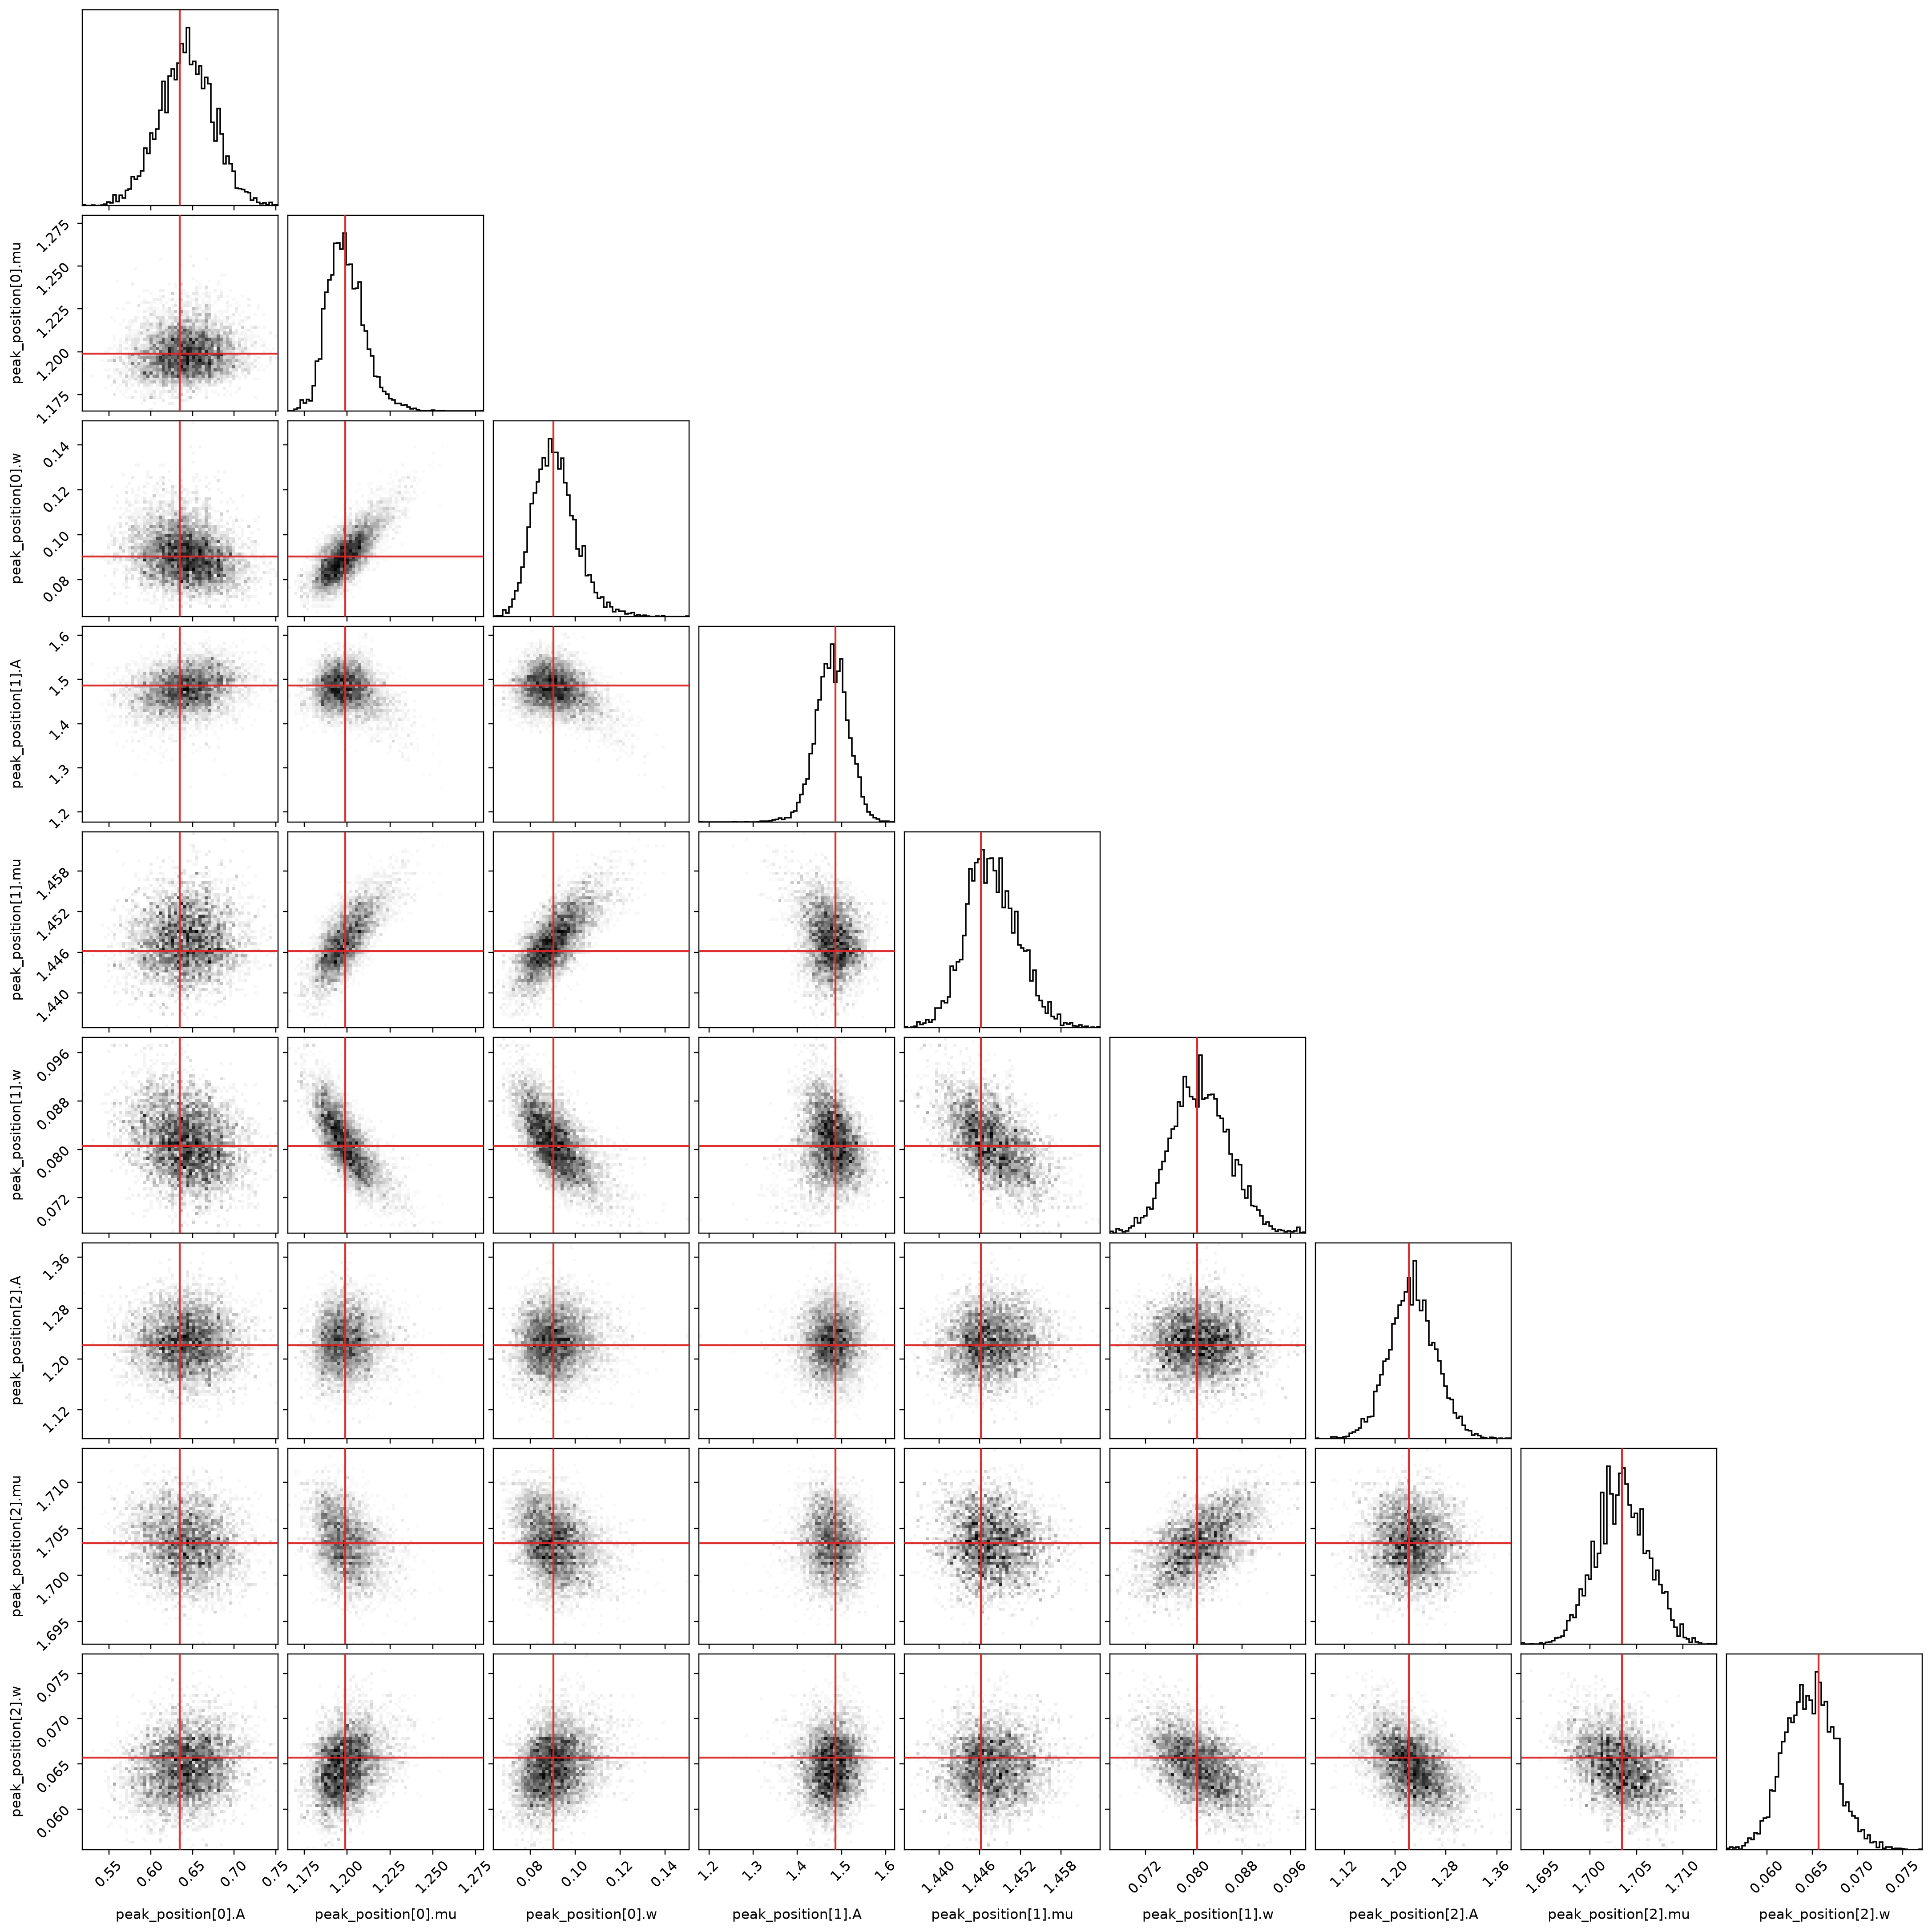

In [9]:
run_cli("plot", "result/sample.json", "--sort-peaks-by", "mu")
figure_candidates = [RESULT_DIR / "figures" / "corner.png", RESULT_DIR / "figures" / "posterior.svg"]
posterior_figure = next((path for path in figure_candidates if path.exists()), None)
print(posterior_figure.relative_to(PROJECT_DIR) if posterior_figure else "posterior figure was not created")
if posterior_figure and "ipykernel" in sys.modules:
    from IPython.display import Image as NotebookImage, SVG, display

    if posterior_figure.suffix.lower() == ".png":
        display(NotebookImage(filename=str(posterior_figure)))
    else:
        display(SVG(filename=str(posterior_figure)))

95%信用区間は「このモデル、事前分布、観測データのもとで、パラメータがこの区間に入る事後確率が
95%」という意味です。頻度論の信頼区間とは定義が異なります。また、重なったピークでは
$A_k$ と $w_k$、隣接する $\mu_k$ 同士などに相関が生じるため、1変数ずつの幅だけでなく同時分布も確認します。

## 8. 各ピークと合成スペクトルの不確かさを描く

事後サンプルごとにスペクトルを再構成すれば、パラメータの不確かさをスペクトル上の帯として表せます。
ここで描く帯はノイズを新しく足した観測値の範囲ではなく、ノイズを除いた平均スペクトルの不確かさです。

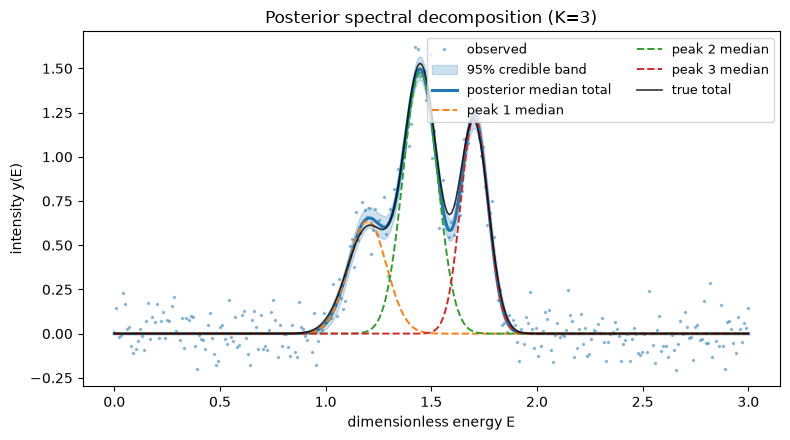

In [10]:
draw_count = min(500, posterior.shape[0])
draw_indices = np.linspace(0, posterior.shape[0] - 1, draw_count, dtype=int)
component_draws = np.empty((draw_count, K_TRUE, N))
for draw_position, sample_index in enumerate(draw_indices):
    for peak_index, (A, mu, w) in enumerate(posterior[sample_index]):
        component_draws[draw_position, peak_index] = gaussian_peak(energy, A, mu, w)
total_draws = component_draws.sum(axis=1)

total_low, total_median, total_high = np.quantile(total_draws, [0.025, 0.5, 0.975], axis=0)
component_medians = np.median(component_draws, axis=0)

fig, ax = plt.subplots(figsize=(8.0, 4.5))
ax.plot(energy, observed, ".", ms=3, alpha=0.40, label="observed")
ax.fill_between(energy, total_low, total_high, color="C0", alpha=0.22, label="95% credible band")
ax.plot(energy, total_median, color="C0", lw=2.2, label="posterior median total")
for index, curve in enumerate(component_medians, start=1):
    ax.plot(energy, curve, "--", lw=1.4, label=f"peak {index} median")
ax.plot(energy, true_signal, color="black", lw=1.2, alpha=0.8, label="true total")
ax.set(xlabel="dimensionless energy E", ylabel="intensity y(E)", title="Posterior spectral decomposition (K=3)")
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()
plt.show()

## 9. ベイズ自由エネルギーからピーク数を選ぶ

次に $K=1,\ldots,6$ を候補とし、それぞれについてEMCを実行します。`fixed-noise` は全候補で
同じ既知雑音分散 $\sigma^2=0.01$ を使い、EMC温度列から得た $F(K)$ を直接比較する指定です。
最小の $F(K)$ を与えるピーク数を $K^*$ とします。ここではモデルの事前確率を
$p(K)=1/6$ と置くので、$p(K\mid\boldsymbol y)\propto\exp[-F(K)]$ です。

In [11]:
selection_config = json.loads(runtime_path.read_text(encoding="utf-8"))
selection_config["emc"]["sample_num"] = 400 if FAST_MODE else 10000
selection_config["emc"]["burnin_num"] = 600 if FAST_MODE else 10000
selection_path = PROJECT_DIR / "config.model_selection.runtime.json"
selection_path.write_text(json.dumps(selection_config, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")

run_cli(
    "select-peaks",
    selection_path.name,
    "--min",
    "1",
    "--max",
    "6",
    "--criterion",
    "fixed-noise",
)

$ python -m bayes_emc select-peaks config.model_selection.runtime.json --min 1 --max 6 --criterion fixed-noise


samples: 10000
map_log_posterior: -450.324
fixed_sigma2: 0.01
noise_free_energy: 50.6823
diagnostic_warnings: 2
gaussian_peaks[0].default.A: 1.24794
gaussian_peaks[0].default.mu: 1.48255
gaussian_peaks[0].default.w: 0.199996
samples: 10000
map_log_posterior: -254.857
fixed_sigma2: 0.01
noise_free_energy: -136.621
diagnostic_warnings: 0
gaussian_peaks[0].default.A: 1.18575
gaussian_peaks[0].default.mu: 1.42369
gaussian_peaks[0].default.w: 0.17527
gaussian_peaks[1].default.A: 0.937537
gaussian_peaks[1].default.mu: 1.71808
gaussian_peaks[1].default.w: 0.0497948
samples: 10000
map_log_posterior: -142.723
fixed_sigma2: 0.01
noise_free_energy: -237.986
diagnostic_warnings: 0
gaussian_peaks[0].default.A: 1.48605
gaussian_peaks[0].default.mu: 1.44618
gaussian_peaks[0].default.w: 0.0805596
gaussian_peaks[1].default.A: 1.22178
gaussian_peaks[1].default.mu: 1.70346
gaussian_peaks[1].default.w: 0.0656704
gaussian_peaks[2].default.A: 0.634886
gaussian_peaks[2].default.mu: 1.1988
gaussian_peaks[2].d

selected K*: 3
  K=1: F=50.682268, delta F=288.668, p(K|y)=0.0000
  K=2: F=-136.620569, delta F=101.366, p(K|y)=0.0000
* K=3: F=-237.986131, delta F=0.000, p(K|y)=0.4855
  K=4: F=-237.704350, delta F=0.282, p(K|y)=0.3662
  K=5: F=-236.636575, delta F=1.350, p(K|y)=0.1259
  K=6: F=-234.909689, delta F=3.076, p(K|y)=0.0224


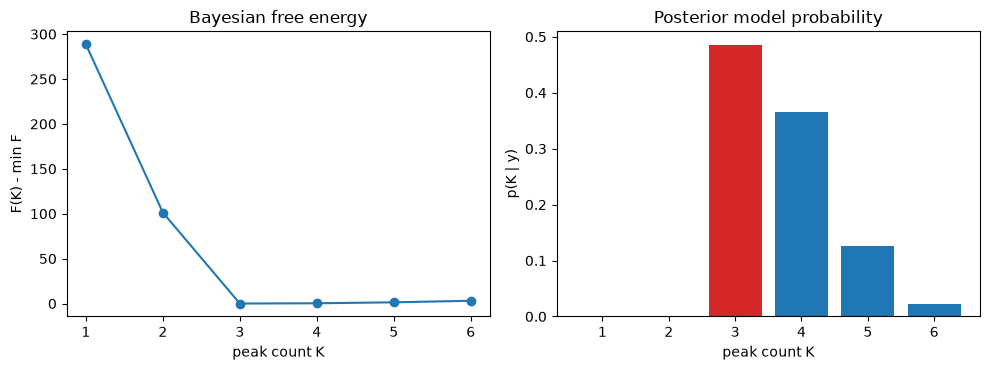

In [12]:
selection_result_path = RESULT_DIR / "model_selection" / "peak_count" / "peak_selection.json"
selection = json.loads(selection_result_path.read_text(encoding="utf-8"))
peak_counts = np.array([item["peak_count"] for item in selection["candidates"]], dtype=int)
free_energies = np.array([item["score"] for item in selection["candidates"]], dtype=float)
relative_free_energy = free_energies - free_energies.min()
posterior_K = np.exp(-relative_free_energy)
posterior_K /= posterior_K.sum()

print(f"selected K*: {selection['selected_peak_count']}")
for K, F, delta_F, probability in zip(peak_counts, free_energies, relative_free_energy, posterior_K):
    marker = "*" if K == selection["selected_peak_count"] else " "
    print(f"{marker} K={K}: F={F:.6f}, delta F={delta_F:.3f}, p(K|y)={probability:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.8))
axes[0].plot(peak_counts, relative_free_energy, "o-", color="C0")
axes[0].set(xlabel="peak count K", ylabel="F(K) - min F", title="Bayesian free energy")
axes[0].set_xticks(peak_counts)
axes[1].bar(peak_counts, posterior_K, color=["C3" if K == selection["selected_peak_count"] else "C0" for K in peak_counts])
axes[1].set(xlabel="peak count K", ylabel="p(K | y)", title="Posterior model probability")
axes[1].set_xticks(peak_counts)
fig.tight_layout()
plt.show()

同梱した通常設定の実行結果では $K=3$ が最小ですが、$K=4$ との差は
$\Delta F\approx0.28$、モデル事後確率はそれぞれ約0.49と0.37です。したがって、
**3本が最も支持されたが、4本を強く排除できるほど決定的ではない**と読みます。
`BAYES_XPS_FAST=1` は配線確認用なので、短い実行では順位や数値が変わることがあります。

## 10. 結果の読み方と次の一歩

- $K<K^*$ ではピーク構造を十分に表せず、残差が大きくなります。
- $K>K^*$ では局所的な当てはまりが改善しても、広い追加パラメータ空間が周辺尤度を下げ得ます。
- $F(K)$ の差が小さい候補がある場合、「ピーク数が一意に確定した」と言い切らず、モデル不確かさを報告します。
- 現在のCoreは $F(K)$ の標準誤差を自動出力しません。近接した候補は、複数seedと計算量を増やした再実行で確認します。
- 事前分布の範囲は周辺尤度に直接効きます。実測データでは物理的根拠を記録し、範囲を変えた感度解析を行います。
- 同じseedの1回だけでなく、seed、温度列、サンプル数を変えて $F(K)$ と事後分布の安定性を確認します。

実測XPSへの発展では、`TargetFunction` に背景 $b(E)$、Voigtまたはpseudo-Voigt形状、doublet制約などを
順に追加します。最初からすべてを自由にすると識別不能性が強くなるため、既知の物理制約を事前分布と
パラメータ共有に反映することが重要です。

### 演習

1. `TRUE_PEAKS` の中央と右の $\mu$ を近づけ、信用区間と相関がどう変わるか確認する。
2. $A_k$ または $w_k$ の事前範囲を広げ、$F(K)$ が事前分布に依存することを確認する。
3. `SIGMA2` を誤って小さく固定し、過剰なピーク数が選ばれやすくなるか確認する。
4. 線形背景 $b(E)=c_0+c_1E$ を生成モデルと推論モデルの両方へ追加する。